# NFL Data Analysis Example

This notebook shows how to connect to the NFL database and perform basic analysis.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Connect to the NFL database
db_path = Path('../data/nfl.duckdb')
conn = duckdb.connect(str(db_path))

print(f"Connected to database: {db_path}")
print("Database connection established successfully!")

Connected to database: ../data/nfl.duckdb
Database connection established successfully!


In [8]:
# parameters
down = 3
season = 2025
play_type = 'pass'
ydstogo = (0,100)

q = f"""

with series as (
    select posteam,
            defteam,
            week,
            season,
            series,
            play_id,
            game_id,
            season_type,
            series_success,
            down,
            yrdln,
            ydstogo,
            pbp.desc,
            play_type,
            epa
    from pbp 
            where 1=1
                    and season in (2020,2021,2022,2023,2024,2025)
    group by all
          
    )
, last_play as (
        select 
            series,
            game_id,
            max(play_id) as play_id
        from series
        group by all
)
, last_play_info as (
    select
        lp.series,
        lp.game_id,
        lp.play_id,
        s.play_type,
        s.desc
    from
            last_play lp
        left join series s
        using(game_id,play_id)
)
, series_summary as (
           select  
            posteam,
            defteam,
            week,
            season,
            game_id,
            season_type,
            series,
            series_success,
            sum(case when down = 3 
            then 1 else 0  end) > 0 as series_third_down,
            count(*) as plays
            
        from
            series
        group by all
    )
    select
        ss.*
        , lpi.play_type as last_play_type
        , lpi.desc as last_play_desc
    from
        series_summary ss
        left join last_play_info lpi
        using(game_id,series)
    order by game_id,series
            """
pd.read_sql(q,conn)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df = pd.read_sql_query(q, conn)
#df.head()

df[df.defteam=='BUF']

def_s = df.groupby(['defteam','posteam','season','week','season_type']).agg(series_count=('series','count'),
                                    series_third_down_count=('series_third_down','sum')
                                    ,series_success_count=('series_success','sum')
                                    ).reset_index()

def_s['def_series_success_rate'] = 1- (def_s['series_success_count']/def_s['series_count'])
                            
median = def_s.def_series_success_rate.describe()['50%']
l25 = def_s.def_series_success_rate.describe()['25%']
l75 = def_s.def_series_success_rate.describe()['75%']


def_s[def_s.defteam=='BUF'].sort_values(['season','week']).tail()


,defteam,posteam,season,week,season_type,series_count,series_third_down_count,series_success_count,def_series_success_rate
357,BUF,NO,2025,4,REG,29,13,21.0,0.275862
355,BUF,NE,2025,5,REG,29,10,21.0,0.275862
287,BUF,ATL,2025,6,REG,30,15,22.0,0.266667
294,BUF,CAR,2025,8,REG,29,11,19.0,0.344828
323,BUF,KC,2025,9,REG,24,13,16.0,0.333333


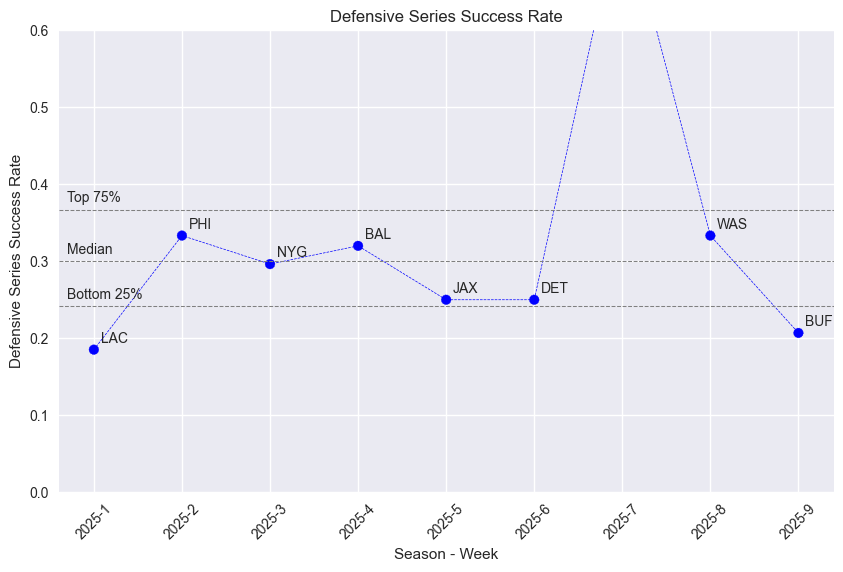

In [9]:
## series success rate

team='KC'
season=2025


bills = def_s[(def_s.defteam==team)&(def_s.season==season)].sort_values(['season','week'])

bills['season_week'] = bills.season.astype(str) + '-' + bills.week.astype(str)


# Create a color map for season_type
color_map = {'REG': 'blue', 'POST': 'purple'}
colors = [color_map[season_type] for season_type in bills['season_type']]

marker_map = {'REG': 'o', 'POST': '*'}
markers = [marker_map[season_type] for season_type in bills['season_type']]

fg, ax = plt.subplots(figsize=(10,6))


ax.scatter(bills.season_week
            ,bills.def_series_success_rate
            ,linestyle='--'

            ,color=colors)

ax.plot(bills.season_week
            ,bills.def_series_success_rate
            ,linestyle='--'
            ,linewidth=.5
            ,color='blue')


ax.set_title('Defensive Series Success Rate')
ax.set_xlabel('Season - Week')
ax.set_ylabel('Defensive Series Success Rate')
ax.axhline(y=l25,color='gray',linestyle='--',linewidth=.75)
ax.axhline(y=l75,color='gray',linestyle='--',linewidth=.75)
ax.set_ylim(0,.6)
ax.axhline(y=median,color='gray',linestyle='--',linewidth=.75)

# Add text labels for the horizontal lines
# Get the x-axis limits to position text at the left edge
x_min, x_max = ax.get_xlim()
ax.text(x_min + 0.1, l25 + 0.01, 'Bottom 25%', fontsize=10,  ha='left')
ax.text(x_min + 0.1, median + 0.01, 'Median', fontsize=10,  ha='left')
ax.text(x_min + 0.1, l75 + 0.01, 'Top 75%', fontsize=10,  ha='left')

ax.tick_params(axis='x', rotation=45)

# Fix the annotation - use correct coordinates
for i, team in enumerate(bills['posteam']):
    ax.annotate(team, 
                (bills['season_week'].iloc[i]
                    , bills['def_series_success_rate'].iloc[i]), 
                xytext=(5, 5),  # Offset the text slightly
                textcoords='offset points',
                fontsize=10,
                ha='left')

plt.show()



<Axes: title={'center': 'Defensive Series Success Rate'}, xlabel='Season - Week', ylabel='Defensive Series Success Rate'>

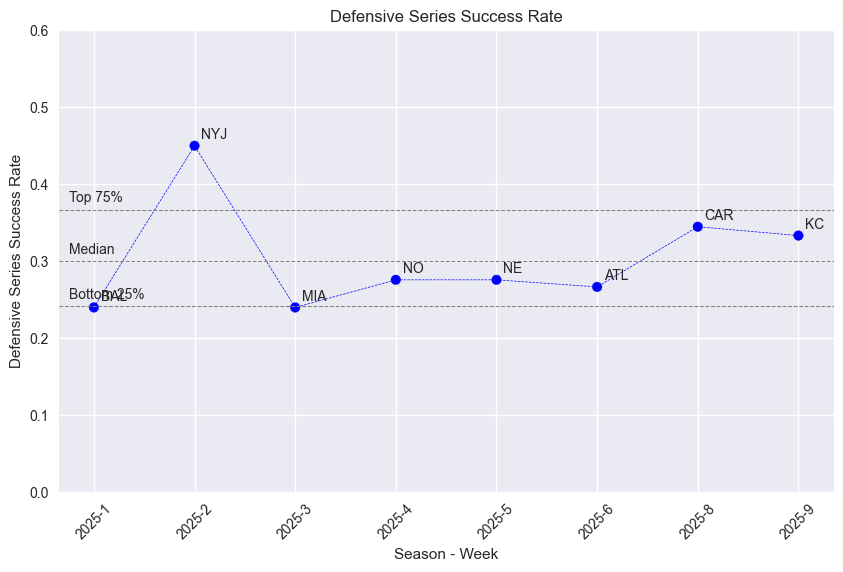

In [13]:
def query_data(team,season):
        q = f"""

    with series as (
        select posteam,
                defteam,
                week,
                season,
                series,
                play_id,
                game_id,
                season_type,
                series_success,
                down,
                yrdln,
                ydstogo,
                pbp.desc,
                play_type,
                epa
        from pbp 
                where 1=1
                        and season in (2020,2021,2022,2023,2024,2025)
        group by all
            
        )
    , last_play as (
            select 
                series,
                game_id,
                max(play_id) as play_id
            from series
            group by all
    )
    , last_play_info as (
        select
            lp.series,
            lp.game_id,
            lp.play_id,
            s.play_type,
            s.desc
        from
                last_play lp
            left join series s
            using(game_id,play_id)
    )
    , series_summary as (
            select  
                posteam,
                defteam,
                week,
                season,
                game_id,
                season_type,
                series,
                series_success,
                sum(case when down = 3 
                then 1 else 0  end) > 0 as series_third_down,
                count(*) as plays
                
            from
                series
            group by all
        )
        select
            ss.*
            , lpi.play_type as last_play_type
            , lpi.desc as last_play_desc
        from
            series_summary ss
            left join last_play_info lpi
            using(game_id,series)
        order by game_id,series
                """
        return pd.read_sql(q,conn)


def trend_data(team,season):
    df = query_data(team,season)

    df[df.defteam==team]

    def_s = df.groupby(['defteam','posteam','season','week','season_type']).agg(series_count=('series','count'),
                                        series_third_down_count=('series_third_down','sum')
                                        ,series_success_count=('series_success','sum')
                                        ).reset_index()

    def_s['def_series_success_rate'] = 1- (def_s['series_success_count']/def_s['series_count'])
                                
    median = def_s.def_series_success_rate.describe()['50%']
    l25 = def_s.def_series_success_rate.describe()['25%']
    l75 = def_s.def_series_success_rate.describe()['75%']

    team_df = def_s[(def_s.defteam==team)&(def_s.season==season)].sort_values(['season','week'])

    team_df['season_week'] = team_df.season.astype(str) + '-' + team_df.week.astype(str)

    return team_df, l25, median, l75

def season_trend_plot(team,season):
    
    team_df, l25, median, l75 = trend_data(team,season)

    # Create a color map for season_type
    color_map = {'REG': 'blue', 'POST': 'purple'}
    colors = [color_map[season_type] for season_type in team_df['season_type']]

    marker_map = {'REG': 'o', 'POST': '*'}
    markers = [marker_map[season_type] for season_type in team_df['season_type']]

    fg, ax = plt.subplots(figsize=(10,6))


    ax.scatter(team_df.season_week
                ,team_df.def_series_success_rate
                ,linestyle='--'

                ,color=colors)

    ax.plot(team_df.season_week
                ,team_df.def_series_success_rate
                ,linestyle='--'
                ,linewidth=.5
                ,color='blue')


    ax.set_title('Defensive Series Success Rate')
    ax.set_xlabel('Season - Week')
    ax.set_ylabel('Defensive Series Success Rate')
    ax.axhline(y=l25,color='gray',linestyle='--',linewidth=.75)
    ax.axhline(y=l75,color='gray',linestyle='--',linewidth=.75)
    ax.set_ylim(0,.6)
    ax.axhline(y=median,color='gray',linestyle='--',linewidth=.75)

    # Add text labels for the horizontal lines
    # Get the x-axis limits to position text at the left edge
    x_min, x_max = ax.get_xlim()
    ax.text(x_min + 0.1, l25 + 0.01, 'Bottom 25%', fontsize=10,  ha='left')
    ax.text(x_min + 0.1, median + 0.01, 'Median', fontsize=10,  ha='left')
    ax.text(x_min + 0.1, l75 + 0.01, 'Top 75%', fontsize=10,  ha='left')

    ax.tick_params(axis='x', rotation=45)

    # Fix the annotation - use correct coordinates
    for i, team in enumerate(team_df['posteam']):
        ax.annotate(team, 
                    (team_df['season_week'].iloc[i]
                        , team_df['def_series_success_rate'].iloc[i]), 
                    xytext=(5, 5),  # Offset the text slightly
                    textcoords='offset points',
                    fontsize=10,
                    ha='left')

    return ax

season_trend_plot('BUF',2025)

In [84]:
def rank_plot(df
            ,selected_team
            ,color='Blue'):


    plt.figure(figsize=(3, 4.5))
    plt.rcParams.update({'font.size': 12,
                         'font.family': 'Times New Roman',})  # Set base font size
    # Create colors array - blue for selected team, gray for others
    colors = [color if team == selected_team else 'gray' for team in df['posteam']]

    # Create horizontal dot plot with team names on y-axis
    plt.scatter(df['success_rate'], range(len(df)), c=colors, s=20)

    # Add vertical lines for quartiles
    plt.axvline(x=q25
                , color='red'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Q1 ({q25:.3f})')
    plt.axvline(x=median
                , color='gray'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Median ({median:.3f})')
    plt.axvline(x=q75
                , color='green'
                , linestyle='--'
                , alpha=0.7
                , linewidth=.5
                , label=f'Q3 ({q75:.3f})')

    # Set y-axis labels with colors
    plt.yticks(range(len(df)), df['posteam'])
    plt.xlabel('Success rate')
    plt.title(f'{season} Success Rate - {down} Down, {play_type} ')
    plt.gca().invert_yaxis()  # Reverse order so best is on top
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.yticks(fontsize=8)

    return plt

### things to do:
- make this a function that takes down and team paramaters


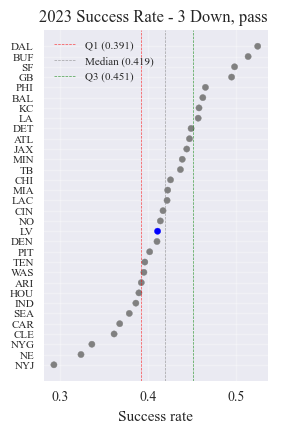

In [ ]:
selected_team = 'LV'
color = 'blue'

# Create horizontal dot plot with team names on y-axis
plt.figure(figsize=(3, 4.5))
plt.rcParams.update({'font.size': 12,
'font.family': 'Times New Roman',})  # Set base font size
# Create colors array - blue for selected team, gray for others
colors = [color if team == selected_team else 'gray' for team in df['posteam']]

# Plot the dots
plt.scatter(df['success_rate'], range(len(df)), c=colors, s=20)

# Add vertical lines for quartiles
plt.axvline(x=q25
            , color='red'
            , linestyle='--'
            , alpha=0.7
            , linewidth=.5
            , label=f'Q1 ({q25:.3f})')
plt.axvline(x=median, color='gray', linestyle='--', alpha=0.7, linewidth=.5, label=f'Median ({median:.3f})')
plt.axvline(x=q75, color='green', linestyle='--', alpha=0.7, linewidth=.5, label=f'Q3 ({q75:.3f})')

# Set y-axis labels with colors
plt.yticks(range(len(df)), df['posteam'])
plt.xlabel('Success rate')
plt.title(f'{season} Success Rate - {down} Down, {play_type} ')
plt.gca().invert_yaxis()  # Reverse order so best is on top
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.yticks(fontsize=8)

plt.show()